<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/02_02_neural_network_classification_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
# function made in 02_01 notebook

import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model,x,y):
  # plots the decision boundary created by a model predicting on x.

  # define axis boundaries of plot and create meshgrid
  x_min, x_max = x[:, 0].min()-0.1, x[:,0].max()+0.1 # 0.1 is to have breathing room for the min and max points
  y_min, y_max = x[:, 1].min()-0.1, x[:,1].max()+0.1 # Corrected y_min, y_max to use x[:,1]

  # Create a meshgrid from both linspace arrays
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

  # create x values to make predictions on
  x_in = np.c_[xx.ravel(), yy.ravel()] # np.c_ is a shorthand for the actual funct

  # Make predictions (these will be logits since the last layer is Dense(1) without activation)
  y_pred = model.predict(x_in)

  # check for multi-class (multiple labes for a single input)
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    # we have to reshape our predictions to get it ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  plot_data = y_pred

  # plot the decision boundary
  plt.contourf(xx,yy, plot_data.reshape(xx.shape), cmap = plt.cm.RdYlBu, alpha = 0.7)
  plt.scatter(x[:,0], x[:,1], c = y, s = 40, cmap = plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show() # Ensure plot is displayed

In [3]:
from sklearn.datasets import make_circles

# make 1000 examples
n_samples = 1000

# create circles
x, y = make_circles(n_samples,
                    noise = 0.03)

In [4]:
x,y

(array([[-0.79696902, -0.65795006],
        [-0.64839897, -0.7391888 ],
        [-0.99847291, -0.27857407],
        ...,
        [ 0.56029399, -0.79412338],
        [ 0.08259907, -0.98417088],
        [-0.53236418,  0.5426217 ]]),
 array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
        0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
        0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
        1, 1, 0, 0, 0, 1, 0, 

In [5]:
x[0].shape # this our input shape i.e. what we feed into the model

(2,)

Introducing Non-Linearity to our model

In [6]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation="relu")
])

model_5.compile(loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics = ["accuracy"])

history = model_5.fit(x,y,epochs = 100, verbose=0)

In [7]:
model_5.evaluate(x,y)

# Our model is still doing worse than guessing
# aboslutely no improvement from model_3 even though we change to a non-linear activation function

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4760 - loss: 5.6501


[5.650139808654785, 0.47600001096725464]

In [8]:
# what if we change the nuumber or neurons, layers in conjunction with our activation funct?

model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu", input_shape=(2,)), # Explicitly define input shape
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") # sigmoid gives a value of either 0 or 1, relu uses larger numbers to learn the pattern but cant give a deterministic value
])
model_6.compile( loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
                metrics = ["accuracy"])

model_6.fit(x,y,epochs = 100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model_6.evaluate(x,y)
# this model works!

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9970 - loss: 0.0192


[0.019224805757403374, 0.996999979019165]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


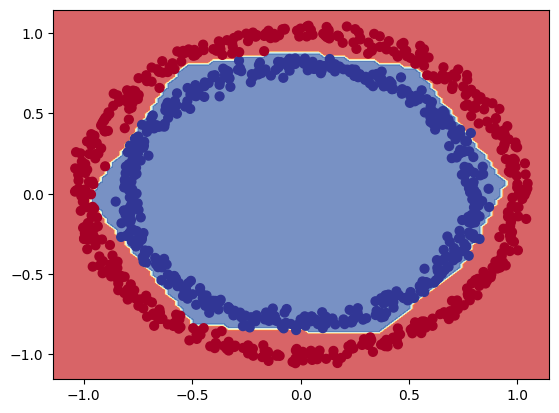

In [10]:
# visualise our predictions using the function we made earlier
plot_decision_boundary(model_6,x,y)

In [11]:
A = tf.cast(tf.range(-10,10), tf.float32)

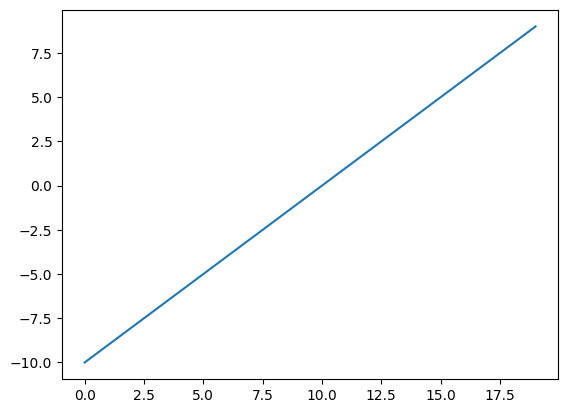

In [12]:
plt.plot(A)

In [13]:
# lets replicate sigmoid: sigmoid(x) = 1/(1+exp(-x)))

def sigmoid(x):
  return 1/(1+tf.exp(-x))

# use sigmoid on our toy tensor

A_sigmoid = sigmoid(A)
A_sigmoid

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397868e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726230e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105854e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

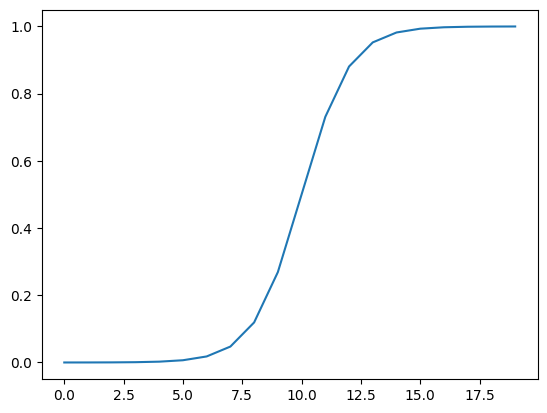

In [14]:
plt.plot(A_sigmoid)

In [15]:
# lets recreate a relu function
def relu(x):
  return tf.maximum(0,x)

relu_A = relu(A)
relu_A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

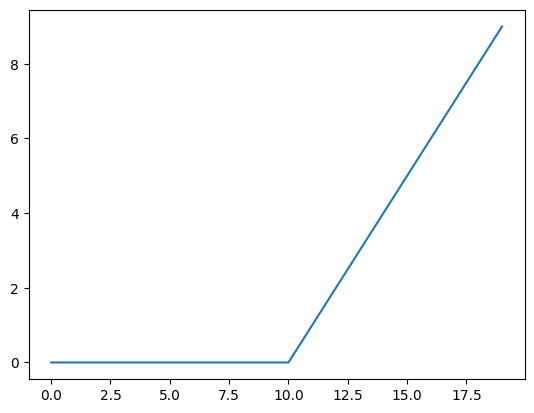

In [16]:
plt.plot(relu_A)

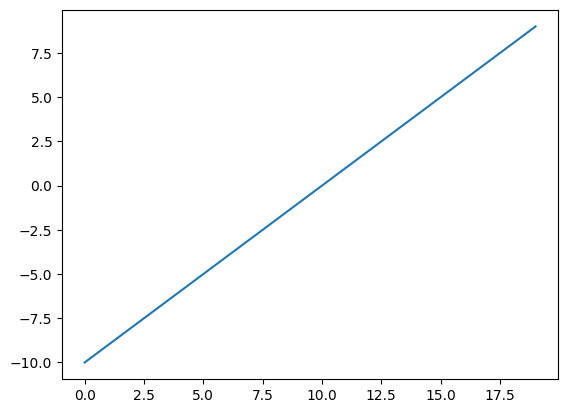

In [17]:
# linear activatio function returns the tensor unmodified

A == tf.keras.activations.linear(A)
plt.plot(tf.keras.activations.linear(A))

### This is why our earlier models coulding understand the circular patterns using the linear activation

Eval and Improve our classification model

In [18]:
# so far we have been training and perdicting on the same dataset, which is not ideal.

len(x), len(y)


(1000, 1000)

In [19]:
# split x,y to training and testing
x_train, y_train = x[:800], y[:800]
x_test, y_test = x[800:], y[800:]

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((800, 2), (200, 2), (800,), (200,))

In [20]:
# create a model to fit on the training data and evaluate on the testing data

model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu", input_shape=[2,]),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_7.compile(loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
                metrics = ["accuracy"]
)

history_model_7 = model_7.fit(x_train, y_train, epochs = 25, verbose=0)


In [21]:
model_7.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (456.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 76 (308.00 B)

In [22]:
model_7.evaluate(x_test, y_test) # bang on!

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9950 - loss: 0.1059


[0.10587818920612335, 0.9950000047683716]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


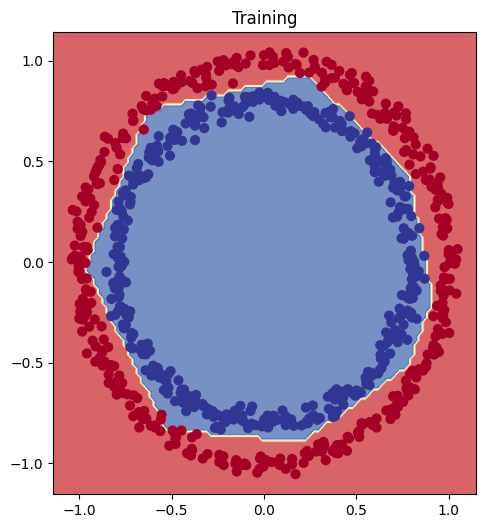

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


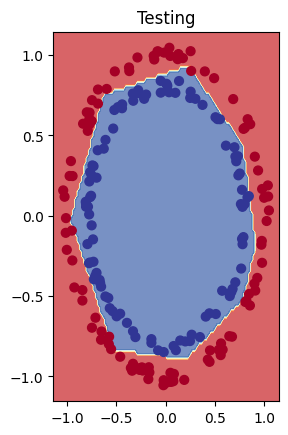

In [23]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training")
plot_decision_boundary(model_7, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing")
plot_decision_boundary(model_7,  x_test, y_test)
plt.show()

Understanding a model's loss curves

In [24]:
# a history object returnsa model's training loss values

history_model_7.history # this is for model_7
# it gives us the loss at each epoch

{'accuracy': [0.49000000953674316,
  0.48875001072883606,
  0.5387499928474426,
  0.5799999833106995,
  0.5712500214576721,
  0.6337500214576721,
  0.5899999737739563,
  0.6812499761581421,
  0.7162500023841858,
  0.7549999952316284,
  0.7674999833106995,
  0.78125,
  0.8062499761581421,
  0.8512499928474426,
  0.9012500047683716,
  0.9325000047683716,
  0.9487500190734863,
  0.9624999761581421,
  0.9787499904632568,
  0.9837499856948853,
  0.9837499856948853,
  0.9900000095367432,
  0.9912499785423279,
  0.9912499785423279,
  0.9887499809265137],
 'loss': [0.7030010223388672,
  0.6944947838783264,
  0.6878318786621094,
  0.6830976009368896,
  0.6747294664382935,
  0.6671401262283325,
  0.6503039002418518,
  0.635746955871582,
  0.6070138812065125,
  0.5779076814651489,
  0.5411093831062317,
  0.5077620148658752,
  0.46980467438697815,
  0.43108174204826355,
  0.38319042325019836,
  0.33785107731819153,
  0.2974119186401367,
  0.26661983132362366,
  0.22576473653316498,
  0.19703058898

In [25]:
import pandas as pd
# convert history object into a dataframe

pd.DataFrame(history_model_7.history)

,accuracy,loss
0,0.49000,0.703001
1,0.48875,0.694495
2,0.53875,0.687832
3,0.58000,0.683098
4,0.57125,0.674729
5,0.63375,0.667140
6,0.59000,0.650304
7,0.68125,0.635747
8,0.71625,0.607014
9,0.75500,0.577908


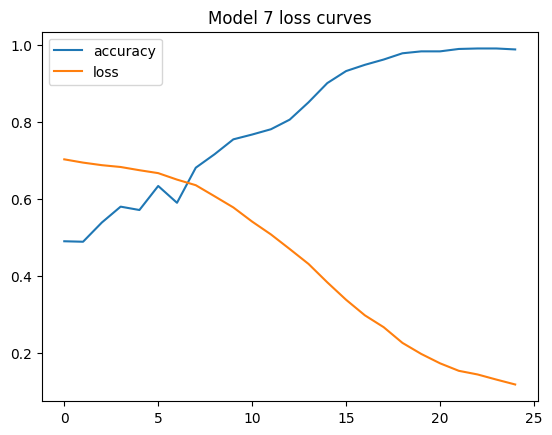

In [26]:
# plot the plot curve
pd.DataFrame(history_model_7.history).plot()
plt.title("Model 7 loss curves");

Utilising callback to optimize learning rate

In [27]:
# create a new model

model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu", input_shape = [2,]),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_8.compile(loss = "BinaryCrossentropy",
                optimizer = "Adam",
                metrics = ["accuracy"])

# create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))
history_model_8 = model_8.fit(x_train, y_train, epochs = 50,
                              callbacks = [lr_scheduler], verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


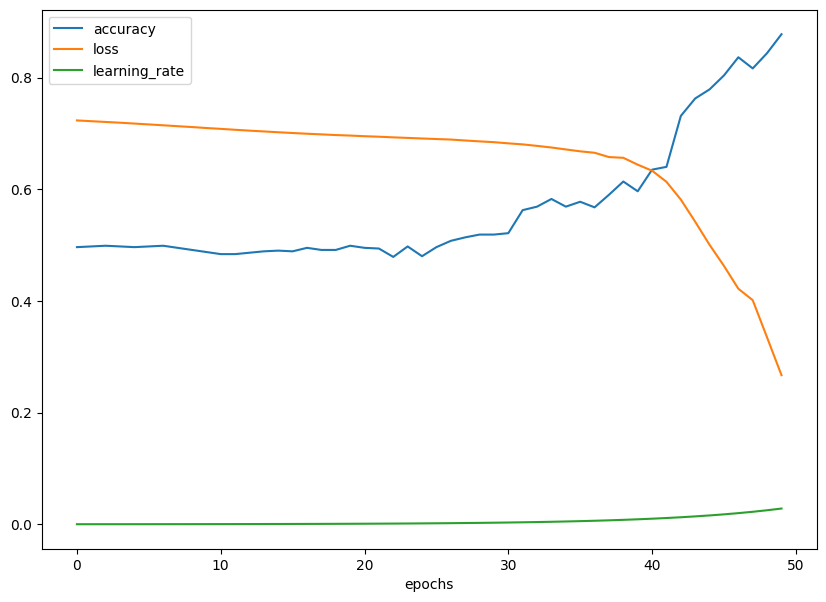

In [28]:
pd.DataFrame(history_model_8.history).plot(figsize=(10,7), xlabel = "epochs");

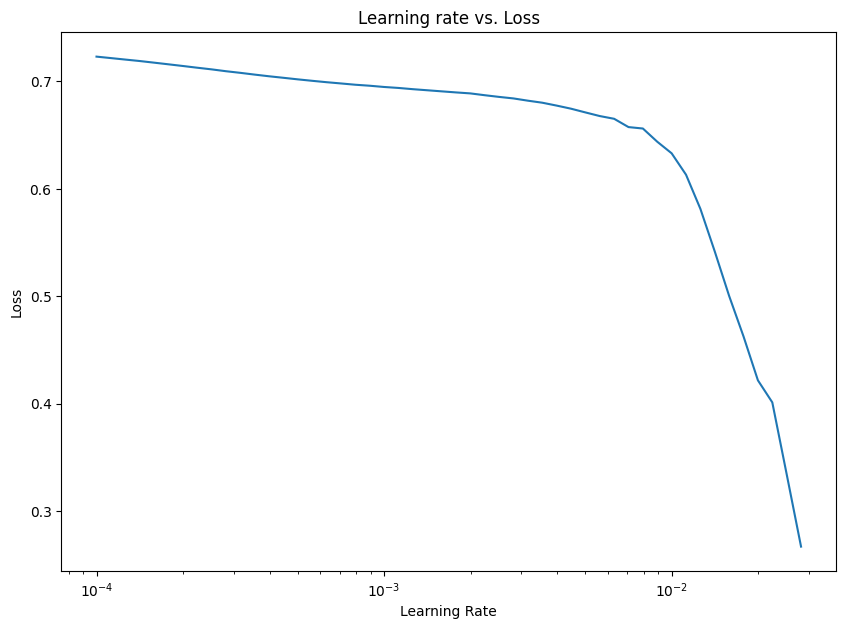

In [29]:
# plot learning rate vs loss

lrs = 1e-4 * (10**(tf.range(50)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history_model_8.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss");

# our ideal learning rate is where loss is reducing the fastest

In [30]:
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu", input_shape = [2,]),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_9.compile(loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.02),
                metrics = ["accuracy"])

history_model_9 = model_9.fit(x_train, y_train, epochs = 25, verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model_7.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9950 - loss: 0.1059 


[0.10587818920612335, 0.9950000047683716]

In [32]:
model_9.evaluate(x_test, y_test)

# loss, acc is improved in the same amount of epochs

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9950 - loss: 0.0368


[0.03680301085114479, 0.9950000047683716]